# Matcher: Export to OpenVINO (INT8) and Run on CPU

This notebook demonstrates the full workflow:

1. **Fit** a Matcher model on a reference image + mask
2. **Export** the fitted model to OpenVINO IR format (default compression to INT8_SYM)
3. **Run inference** with the OpenVINO model on CPU (producing masks AND bounding boxes)
4. **Visualize** the results side-by-side with PyTorch predictions

In [10]:
# Copyright (C) 2026 Intel Corporation
# SPDX-License-Identifier: Apache-2.0

from __future__ import annotations

from pathlib import Path
from time import time

import matplotlib.pyplot as plt
import numpy as np
import openvino
import torch

from instantlearn.components.sam.decoder import masks_to_boxes_traceable
from instantlearn.data import Sample
from instantlearn.data.utils.image import read_image
from instantlearn.models import Matcher
from instantlearn.utils.constants import Backend
from instantlearn.visualizer import render_predictions

In [11]:
EXAMPLES_DIR = Path("assets/coco")
EXPORT_DIR = Path("output/matcher_openvino")

REF_IMAGE = EXAMPLES_DIR / "000000286874.jpg"
REF_MASK = EXAMPLES_DIR / "000000286874_mask.png"
TARGET_IMAGES = [
    EXAMPLES_DIR / "000000390341.jpg",
    EXAMPLES_DIR / "000000173279.jpg",
    EXAMPLES_DIR / "000000267704.jpg",
]

TORCH_DEVICE = "cuda"  # Change to xpu or cpu
OV_DEVICE = "CPU"

## 1. Fit the Matcher model

We use the default `SAM-HQ-tiny` variant (fastest for PyTorch inference).
During OpenVINO export, the model automatically falls back to `SAM-HQ-base`
because SAM-HQ-tiny produces non-deterministic outputs as an OpenVINO IR.

In [12]:
# Uses SAM-HQ-tiny (default) for fast PyTorch inference.
# When exporting to OpenVINO, the export() method will automatically switch to
# SAM-HQ-base and emit a warning — SAM-HQ-tiny is not compatible with OpenVINO.
model = Matcher(
    device=TORCH_DEVICE,
    encoder_model="dinov3_small",
    sam="SAM-HQ-tiny",
    confidence_threshold=0.25,  # Low threshold to show more predictions for visualization
)

ref_sample = Sample(
    image_path=str(REF_IMAGE),
    mask_paths=str(REF_MASK),
)

model.fit(ref_sample)
print("Matcher fitted on reference image.")

Matcher fitted on reference image.


## 2. PyTorch baseline predictions

Run the model in PyTorch to have a baseline for comparison.

In [13]:
target_samples = [Sample(image_path=str(p)) for p in TARGET_IMAGES]
pytorch_preds = model.predict(target_samples)

for i, pred in enumerate(pytorch_preds):
    n_masks = pred["pred_masks"].shape[0]
    scores = pred["pred_scores"]
    print(f"  Target {i}: {n_masks} masks, scores {scores.tolist()}")

  Target 0: 5 masks, scores [0.7925233840942383, 0.7731907367706299, 0.7008827924728394, 0.6861186623573303, 0.61083984375]
  Target 1: 5 masks, scores [0.8320409059524536, 0.7976366281509399, 0.776431679725647, 0.686628520488739, 0.6405261754989624]
  Target 2: 3 masks, scores [0.7981873750686646, 0.7825770974159241, 0.6964126229286194]


## 3. Export to OpenVINO

The export pipeline: PyTorch &rarr; ONNX &rarr; OpenVINO IR (`.xml` + `.bin`).

Reference features from `fit()` are frozen into the graph, so the exported
model takes only a target image as input.

**Note:** Since we initialized with `SAM-HQ-tiny`, the export will log a
warning and automatically use `SAM-HQ-base` for the exported model.

In [5]:
# This will produce a warning: "SAM-HQ-Tiny is not supported for OpenVINO export.
# Falling back to SAM-HQ-base for the exported model."
ov_path = model.export(
    export_dir=EXPORT_DIR,
    backend=Backend.OPENVINO,
)

print(f"Exported to: {ov_path}")
print(f"Files: {[f.name for f in EXPORT_DIR.iterdir()]}")

/home/rgangire/workspace/code/GetiPrompt/geti-instant-learn/library/src/instantlearn/components/sam/predictor.py:452: TracerWarning: Converting a tensor to a Python integer might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  repeat_count = int(tokens.shape[0])
/home/rgangire/workspace/code/GetiPrompt/geti-instant-learn/library/.cuda/lib/python3.13/site-packages/segment_anything_hq/modeling/transformer.py:232: TracerWarning: Converting a tensor to a Python float might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  attn = attn / math.sqrt(c_per_head)
/home/rgangire/workspace/code/GetiPrompt/geti-instant-learn/library/src/instantlearn/components/sam/decoder.py:39: TracerWarni

INFO:nncf:Statistics of the bitwidth distribution:
┍━━━━━━━━━━━━━━━━━━━━━━━━━━━┯━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┯━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┑
│ Weight compression mode   │ % all parameters (layers)   │ % ratio-defining parameters (layers)   │
┝━━━━━━━━━━━━━━━━━━━━━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┿━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┥
│ float                     │ 0% (1 / 185)                │ 0% (0 / 184)                           │
├───────────────────────────┼─────────────────────────────┼────────────────────────────────────────┤
│ int8_sym, per-channel     │ 100% (184 / 185)            │ 100% (184 / 184)                       │
┕━━━━━━━━━━━━━━━━━━━━━━━━━━━┷━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┷━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┙


/home/rgangire/workspace/code/GetiPrompt/geti-instant-learn/library/.cuda/lib/python3.13/site-packages/rich/live.py
:231: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Exported to: output/matcher_openvino/matcher.xml
Files: ['matcher.xml', 'matcher.onnx', 'matcher.bin']


## 4. Load and run the OpenVINO model

Uses `Matcher.prepare_openvino_input` for preprocessing and
`Matcher.resize_masks_to_frame` for postprocessing. Bounding boxes are derived
from the predicted masks using `masks_to_boxes_traceable`.

In [6]:
core = openvino.Core()
ov_model = core.read_model(str(ov_path))
compiled = core.compile_model(ov_model, OV_DEVICE)

input_size = compiled.input(0).shape[2]  # Square input (e.g. 512)
print(f"Model input shape: {compiled.input(0).shape}")
print(f"Outputs: {[o.get_any_name() for o in compiled.outputs]}")

Model input shape: [1,3,512,512]
Outputs: ['masks', 'scores', 'labels']


In [7]:
def predict_openvino(
    compiled_model: openvino.CompiledModel,
    image_path: Path,
    input_size: int,
) -> dict[str, torch.Tensor]:
    """Run inference and return masks, scores, labels, and bounding boxes."""
    # Read image as HWC numpy and preprocess using Matcher's static helper
    image_hwc = read_image(str(image_path), as_tensor=False)
    frame_h, frame_w = image_hwc.shape[:2]
    input_tensor = Matcher.prepare_openvino_input(image_hwc, input_size)

    # Run OpenVINO inference
    result = compiled_model(input_tensor)
    masks, scores, labels = (np.array(v) for v in result.values())

    # Resize masks to original frame dimensions and filter active predictions
    masks = Matcher.resize_masks_to_frame(masks, frame_h, frame_w)
    scores_t = torch.from_numpy(scores)
    keep = scores_t > 0
    masks_t = torch.from_numpy(masks)[keep].to(torch.uint8)
    scores_t = scores_t[keep]
    labels_t = torch.from_numpy(labels)[keep]

    # Derive bounding boxes from masks
    if masks_t.numel() > 0:
        boxes = masks_to_boxes_traceable(masks_t.bool())
        pred_boxes = torch.cat([boxes, scores_t.unsqueeze(1)], dim=1)
    else:
        pred_boxes = torch.zeros(0, 5)

    return {
        "pred_masks": masks_t,
        "pred_scores": scores_t,
        "pred_labels": labels_t,
        "pred_boxes": pred_boxes,
    }

In [8]:
ov_results = []
for img_path in TARGET_IMAGES:
    start = time()
    pred = predict_openvino(compiled, img_path, input_size)
    elapsed = time() - start
    ov_results.append(pred)
    n = pred["pred_masks"].shape[0]
    print(f"  {img_path.name}: {n} masks, {elapsed:.3f}s, boxes shape {pred['pred_boxes'].shape}")

  000000390341.jpg: 1 masks, 1.041s, boxes shape torch.Size([1, 5])
  000000173279.jpg: 1 masks, 1.194s, boxes shape torch.Size([1, 5])
  000000267704.jpg: 1 masks, 1.159s, boxes shape torch.Size([1, 5])


## 5. Visualize: PyTorch vs OpenVINO

Overlay predictions from both backends on the target images.

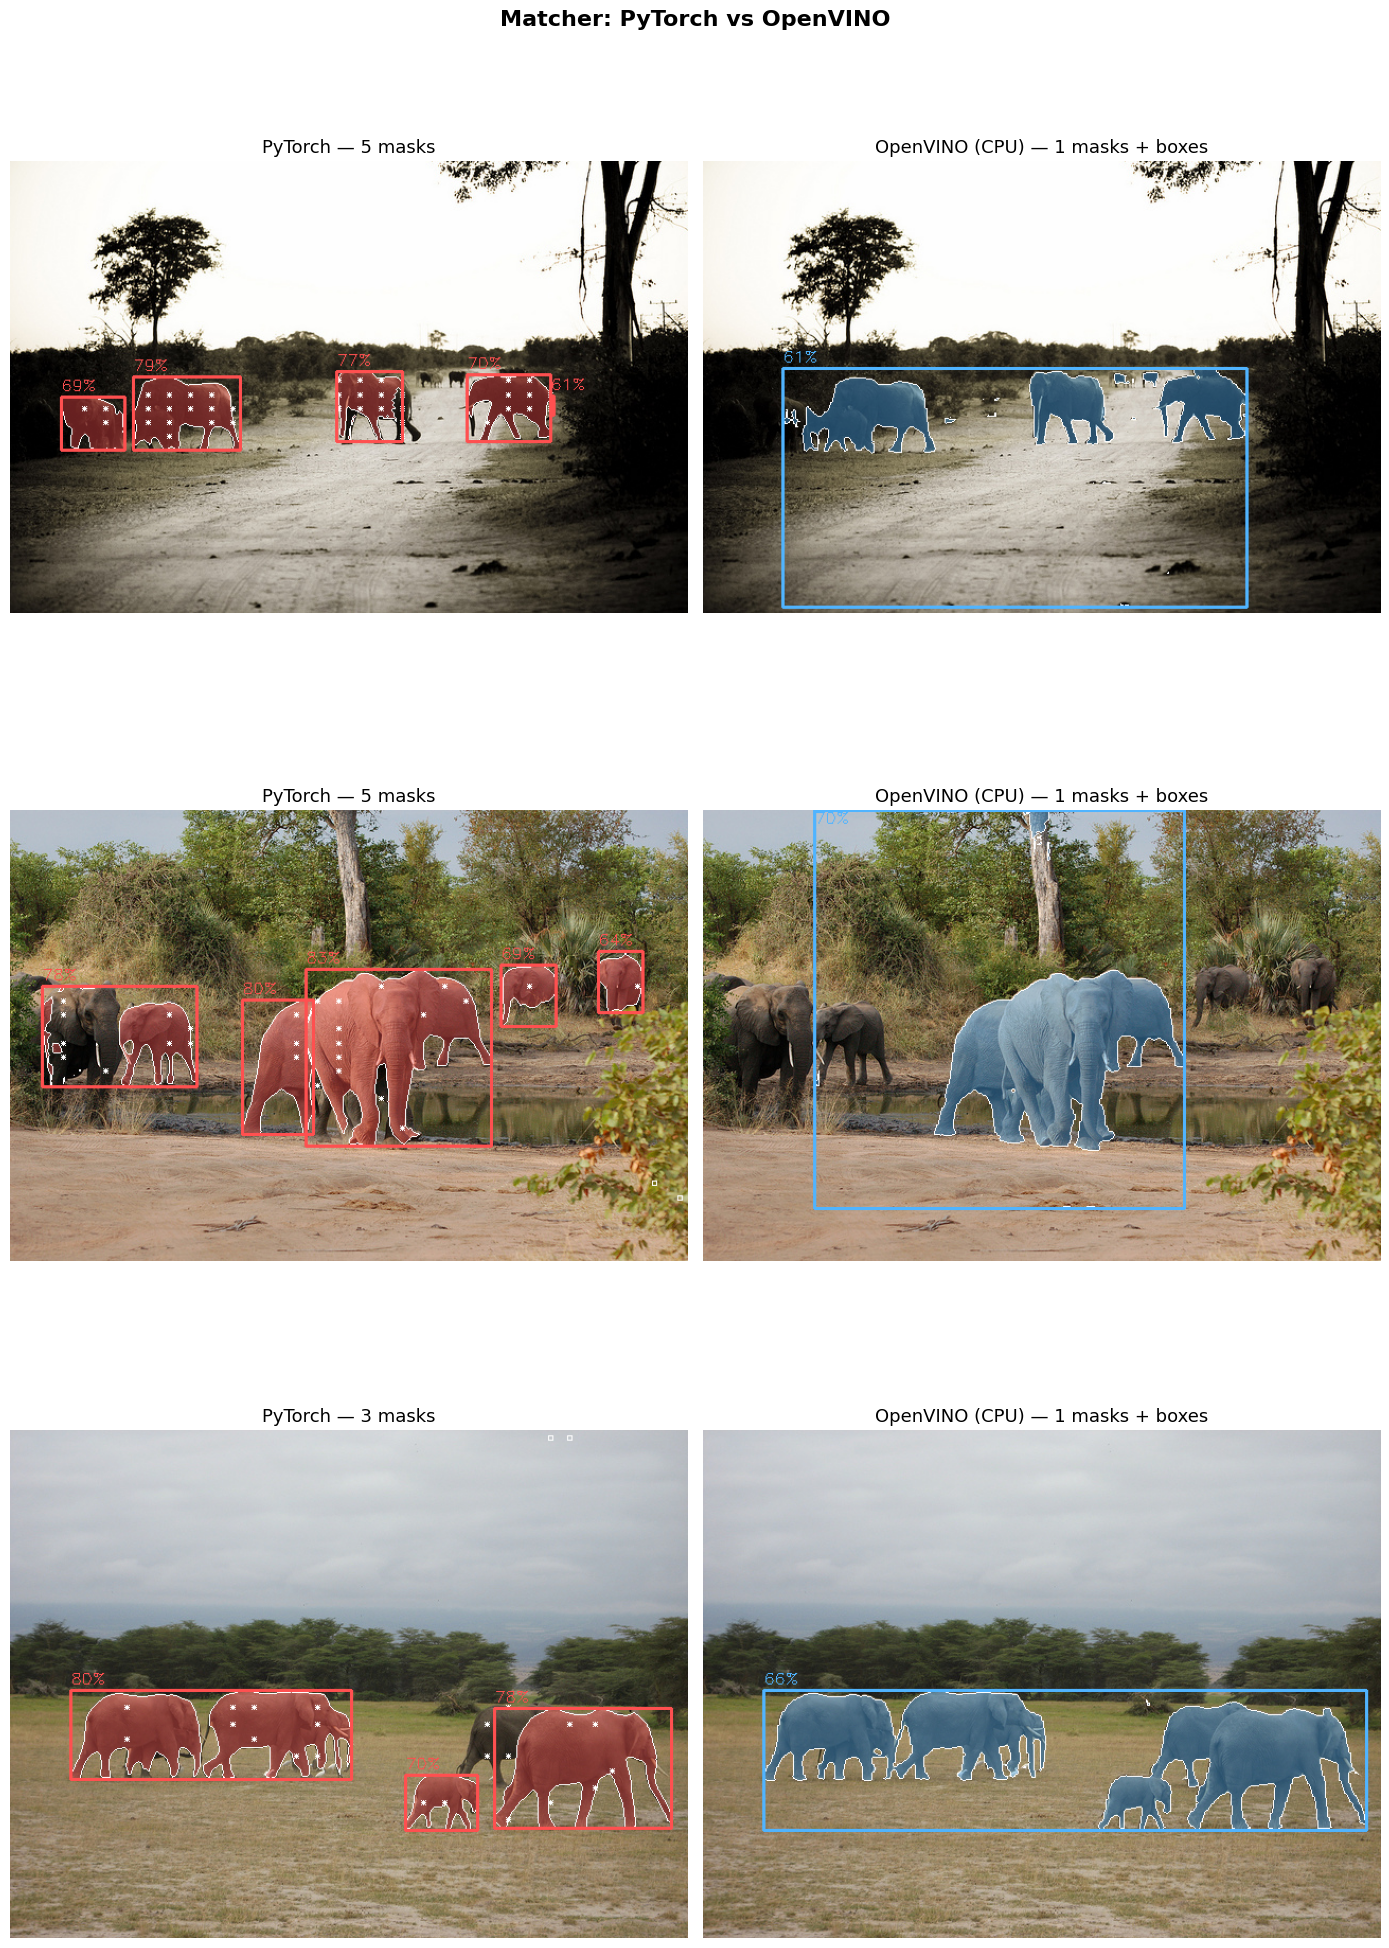

In [ ]:
target_images_np = [read_image(str(p), as_tensor=False) for p in TARGET_IMAGES]

fig, axes = plt.subplots(len(TARGET_IMAGES), 2, figsize=(14, 7 * len(TARGET_IMAGES)))

for row, (img, pt_pred, ov_pred) in enumerate(zip(target_images_np, pytorch_preds, ov_results, strict=False)):
    # PyTorch predictions (left) — remap labels for color map
    n_pt = pt_pred["pred_masks"].shape[0]
    pt_vis = {**pt_pred, "pred_labels": torch.arange(n_pt)}
    cmap_pt = {i: [255, 80, 80] for i in range(n_pt)}
    axes[row, 0].imshow(render_predictions(img, pt_vis, cmap_pt))
    axes[row, 0].set_title(f"PyTorch — {n_pt} masks", fontsize=13)
    axes[row, 0].axis("off")

    # OpenVINO predictions (right) — already has masks, scores, labels, boxes
    n_ov = ov_pred["pred_masks"].shape[0]
    ov_vis = {**ov_pred, "pred_labels": torch.arange(n_ov)}
    cmap_ov = {i: [80, 180, 255] for i in range(n_ov)}
    axes[row, 1].imshow(render_predictions(img, ov_vis, cmap_ov))
    axes[row, 1].set_title(f"OpenVINO ({OV_DEVICE}) — {n_ov} masks + boxes", fontsize=13)
    axes[row, 1].axis("off")

fig.suptitle("Matcher: PyTorch vs OpenVINO", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Currently OpenVINO produces all segmentations in a single mask (semantic and not instance segementation). The PyTorch model produces separate masks for each instance.")